Task 2:
Provide evidence of model fit (e.g., accuracy, loss). Select the best optimizer and activation function for the model and justify your choices. Evaluate potential over-fitting using techniques like dropout.

In [1]:
import pandas as pd

history = pd.read_csv('training_history.csv')
history

,accuracy,auc_3,loss,precision_3,val_accuracy,val_auc_3,val_loss,val_precision_3
0,0.949472,0.939225,0.147477,0.806971,0.962414,0.964716,0.110673,0.901814
1,0.958479,0.958641,0.119430,0.861774,0.963129,0.965223,0.108502,0.927293
2,0.960218,0.960303,0.114801,0.885788,0.966966,0.969187,0.100534,0.911912
3,0.964478,0.965741,0.104955,0.929857,0.969242,0.972937,0.091712,0.952532
4,0.967225,0.968963,0.098300,0.961134,0.970542,0.974443,0.088145,0.984547
5,0.968591,0.970945,0.094071,0.975550,0.970542,0.976291,0.085180,0.966030
6,0.969127,0.972739,0.091194,0.981997,0.971648,0.977627,0.082672,0.995570
7,0.969323,0.973903,0.089001,0.980488,0.971388,0.977923,0.081783,0.976471
8,0.969843,0.974692,0.087819,0.982470,0.972233,0.978332,0.081965,0.990239
9,0.969745,0.975029,0.086906,0.983749,0.968331,0.976449,0.085956,0.898866


In [2]:
predictions = pd.read_csv('predictions_binary.csv')
predictions

,diabetes,diabetes_pred
0,0.0,1.748546e-06
1,0.0,3.821288e-06
2,0.0,1.301579e-07
3,0.0,1.103768e-02
4,0.0,4.504346e-02
...,...,...
19218,0.0,1.437303e-11
19219,1.0,1.000000e+00
19220,0.0,5.683746e-05
19221,0.0,8.779202e-07


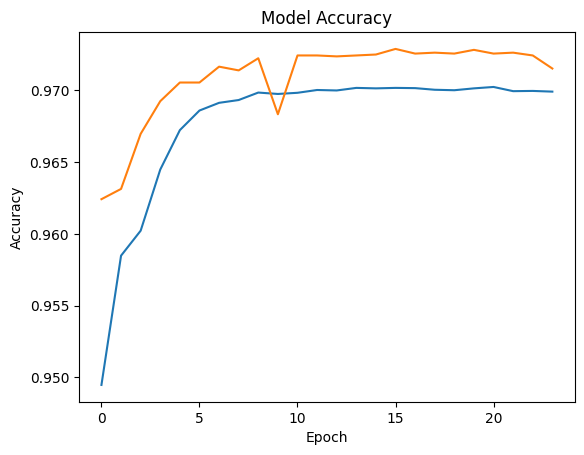

In [3]:
import matplotlib.pyplot as plt

#Plot Accuracy
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

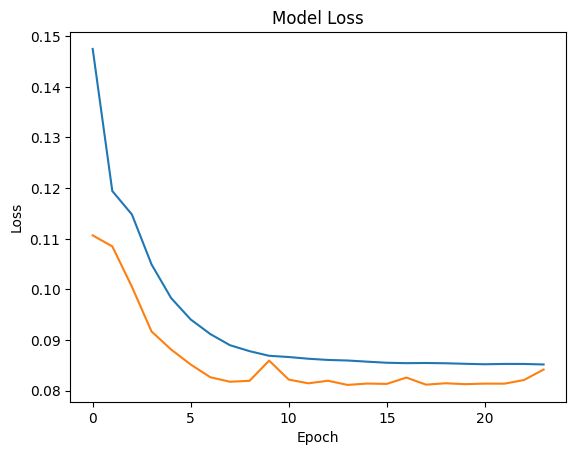

In [4]:
#Plot loss
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

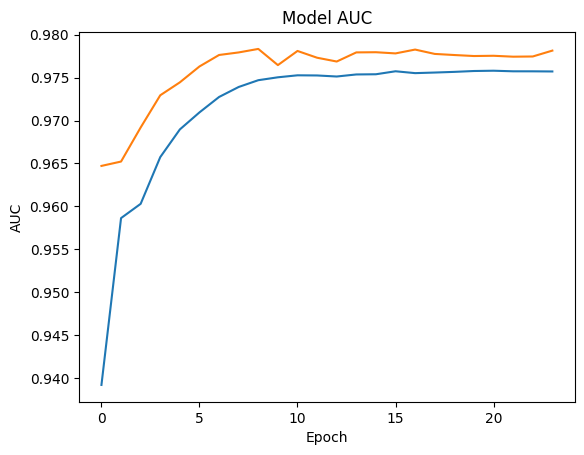

In [5]:
#Plot AUC_3
plt.plot(history['auc_3'])
plt.plot(history['val_auc_3'])
plt.title('Model AUC')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.show()

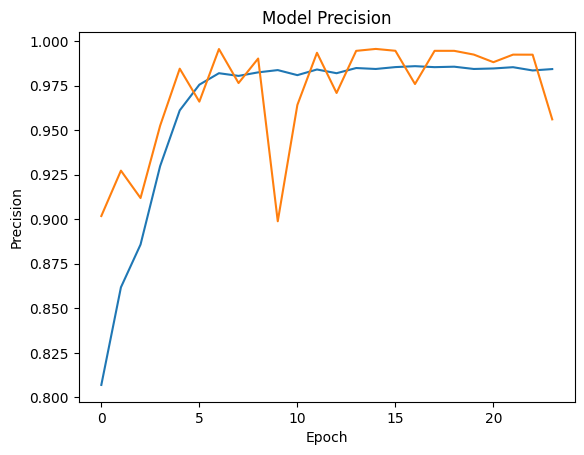

In [6]:
#Plot Precision_3
plt.plot(history['precision_3'])
plt.plot(history['val_precision_3'])
plt.title('Model Precision')
plt.ylabel('Precision')
plt.xlabel('Epoch')
plt.show()

In [7]:
y_test = predictions["diabetes"].values
y_prob = predictions["diabetes_pred"].values

In [8]:
y_pred_binary = (y_prob > 0.5).astype(int)

Confusion Matrix:
[[17457    48]
 [  517  1201]]


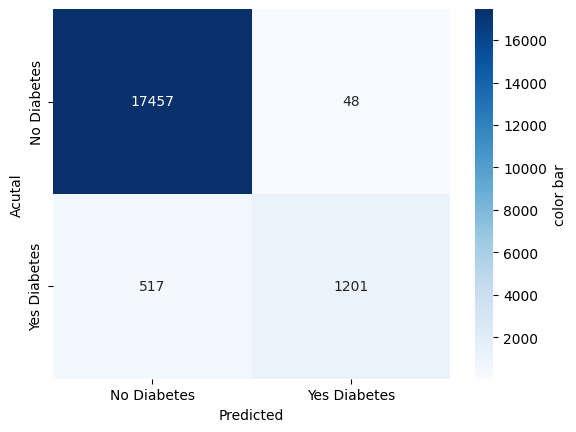

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_binary)
print("Confusion Matrix:")
print(cm)

sns.heatmap(cm, cmap="Blues", annot=True, fmt='g', cbar_kws={"orientation":"vertical", "label":"color bar"},
            xticklabels=["No Diabetes", "Yes Diabetes"], yticklabels=["No Diabetes", "Yes Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Acutal")
plt.show()


In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_binary, target_names=['No Diabetes','Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     17505
    Diabetes       0.96      0.70      0.81      1718

    accuracy                           0.97     19223
   macro avg       0.97      0.85      0.90     19223
weighted avg       0.97      0.97      0.97     19223



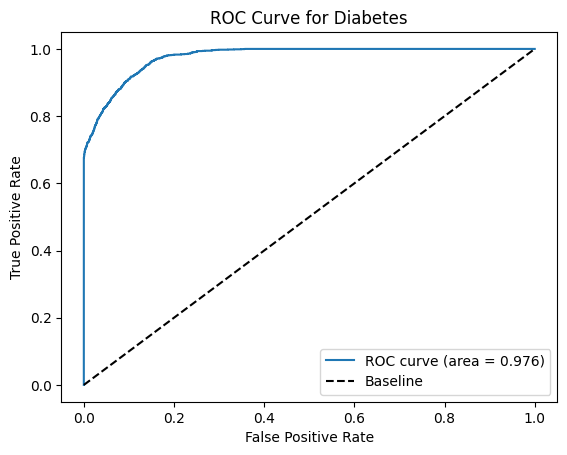

In [11]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label = "ROC curve (area = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], 'k--', label = 'Baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Diabetes")
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metrics_summary = {
    'Accuracy': accuracy_score(y_test, y_pred_binary),
    'Precision (No Diabetes)': precision_score(y_test, y_pred_binary, pos_label=0),
    'Recall (No Diabetes)': recall_score(y_test, y_pred_binary, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred_binary, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred_binary, pos_label=1),
    'Recall (Diabetes)': recall_score(y_test, y_pred_binary, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred_binary, pos_label=1),
    'AUC': roc_auc}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)

                                0
Accuracy                 0.970608
Precision (No Diabetes)  0.971236
Recall (No Diabetes)     0.997258
F1-Score (No Diabetes)   0.984075
Precision (Diabetes)     0.961569
Recall (Diabetes)        0.699069
F1-Score (Diabetes)      0.809572
AUC                      0.976439
